In [1]:
import os
os.chdir(r"E:\Future Interns\Task 3 - Resume  Candidate Screening System\Code")
os.getcwd()

'E:\\Future Interns\\Task 3 - Resume  Candidate Screening System\\Code'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

In [8]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.corpus import stopwords
import re

model = SentenceTransformer("sentence_transformer_model")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1415.15it/s]


In [9]:
stop_words = set(stopwords.words("english"))
def clean_skills(text):
    # split on commas/whitespace
    tokens = re.split(r'[,\s]+', text)
    cleaned = []
    for t in tokens:
        t = t.lower().strip()
        t = re.sub(r'[()]', '', t)          # remove parentheses
        t = t.rstrip('.,)')                  # remove trailing punctuation like "git)" -> "git", "e.g." -> "e.g"
        t = t.strip()
        if t in ('e.g', 'eg', 'ie', 'i.e', '') :
            continue
        if t in stop_words:
            continue
        if len(t) <= 1:                      # drop stray single chars like 'r' from "(python, r)"
            continue
        cleaned.append(t)
    return sorted(set(cleaned))

In [10]:
import joblib

# Load embeddings
jd_embeddings = joblib.load("jd_embeddings.pkl")

# Load JD dataset
jd_df=pd.read_csv("Processed JD.csv")

In [11]:
'''
Sample inputs

1. Matches "web developer / frontend web developer" 
Frontend Developer with 3 years of experience building responsive web applications.
Proficient in HTML, CSS, and JavaScript. Skilled in frontend frameworks including
React and Angular. Strong focus on user experience (UX) design and cross-browser
compatibility. Built and maintained multiple client-facing websites using modern
component-based architecture.

2. Matches "ux/ui designer / user interface designer" 
UX/UI Designer with a strong foundation in visual and interaction design. Experienced
in applying UI design principles and best practices across web and mobile products.
Proficient with graphic design tools such as Adobe Photoshop and Illustrator.
Skilled in typography, color theory, and responsive design for cross-device layouts.

3. Matches "network administrator / network security analyst" 
Network Security Analyst with hands-on experience in network security protocols,
intrusion detection and prevention systems, and firewall administration. Skilled in
vulnerability assessment, log analysis, and security incident response. Familiar with
ethical hacking techniques and enforcing security policies and procedures. Strong
problem-solving and communication skills with close attention to detail.

4. Matches "software tester / quality assurance analyst" 
QA Analyst with solid experience in quality assurance processes and both manual and
automated testing methodologies. Responsible for bug tracking and reporting, test
case development, and regression testing across multiple software releases.

5. Matches "digital marketing specialist / social media manager" (row 0)
Social Media Manager with experience across Facebook, Twitter, and Instagram.
Responsible for content creation and scheduling, tracking social media analytics
and insights, driving community engagement, and managing paid social advertising
campaigns.

'''

'\nSample inputs\n\n1. Matches "web developer / frontend web developer" \nFrontend Developer with 3 years of experience building responsive web applications.\nProficient in HTML, CSS, and JavaScript. Skilled in frontend frameworks including\nReact and Angular. Strong focus on user experience (UX) design and cross-browser\ncompatibility. Built and maintained multiple client-facing websites using modern\ncomponent-based architecture.\n\n2. Matches "ux/ui designer / user interface designer" \nUX/UI Designer with a strong foundation in visual and interaction design. Experienced\nin applying UI design principles and best practices across web and mobile products.\nProficient with graphic design tools such as Adobe Photoshop and Illustrator.\nSkilled in typography, color theory, and responsive design for cross-device layouts.\n\n3. Matches "network administrator / network security analyst" \nNetwork Security Analyst with hands-on experience in network security protocols,\nintrusion detection 

In [12]:
user_input = input("Enter Resume Details: ")
resume_skills = [s.strip().lower() for s in user_input.split()]
jobs = []
matched_counts = []
missing_counts = []
# Encode the WHOLE input as one sentence, matching how JD/resume text was built
resume_text_combined = " ".join(resume_skills)
resume_embedding_pred = model.encode([resume_text_combined], convert_to_numpy=True)

similarity_scores = cosine_similarity(resume_embedding_pred, jd_embeddings)[0]  # shape: (num_jds,)

top_candidates = np.argsort(similarity_scores)[::-1][:5]   # <-- argsort the array, not max()

resume_text = resume_text_combined  # for substring matching below

for rank, idx in enumerate(top_candidates, 1):
    print(f"\nRank {rank}")
    print("Job:", jd_df.iloc[idx]["Job Title"])
    jd_skills = jd_df.iloc[idx]["skills"].split()
    jd_skills = clean_skills(jd_df.iloc[idx]["skills"])
    matched = [skill for skill in jd_skills if skill.lower() in resume_text]
    jobs.append(jd_df.iloc[idx]["Job Title"])
    matched_counts.append(len(matched))
    missing_counts.append(len(jd_skills) - len(matched))
    print("JD Skills      :", jd_skills)
    print("Matched Skills :", matched)
    print("Missing Skills :", list(set(jd_skills) - set(matched)))
    print("-"*100)

Enter Resume Details:  Social Media Manager with experience across Facebook, Twitter, and Instagram. Responsible for content creation and scheduling, tracking social media analytics and insights, driving community engagement, and managing paid social advertising campaigns.



Rank 1
Job: digital marketing specialist
JD Skills      : ['advertising', 'analytics', 'community', 'content', 'creation', 'engagement', 'facebook', 'insights', 'instagram', 'media', 'paid', 'platforms', 'scheduling', 'social', 'twitter']
Matched Skills : ['advertising', 'analytics', 'community', 'content', 'creation', 'engagement', 'facebook', 'insights', 'instagram', 'media', 'paid', 'scheduling', 'social', 'twitter']
Missing Skills : ['platforms']
----------------------------------------------------------------------------------------------------

Rank 2
Job: social media coordinator
JD Skills      : ['adaptability', 'analytics', 'audience', 'communication', 'content', 'creation', 'creative', 'creativity', 'design', 'editing', 'engagement', 'graphic', 'management', 'marketing', 'media', 'optimization', 'production', 'reporting', 'seo', 'skills', 'social', 'storytelling', 'video', 'writing']
Matched Skills : ['analytics', 'content', 'creation', 'engagement', 'media', 'social']
Missi

In [17]:
import hashlib
resume_id = hashlib.md5(resume_text.encode()).hexdigest()[:8]
resume_id

'956e1c35'

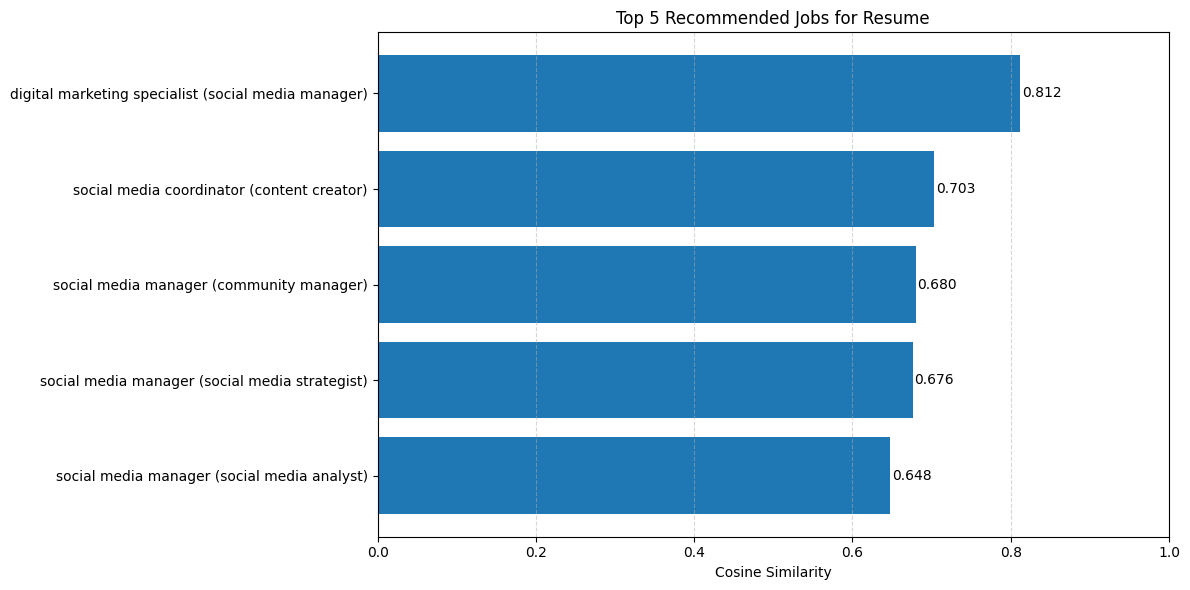

In [20]:
labels = [
    f"{jd_df.iloc[i]['Job Title']} ({jd_df.iloc[i]['Role']})"
    for i in top_candidates
]
similarities = [similarity_scores[i] for i in top_candidates]
plt.figure(figsize=(12,6))
bars = plt.barh(labels[::-1], similarities[::-1])

plt.xlabel("Cosine Similarity")
plt.title(f"Top 5 Recommended Jobs for Resume")

for bar, score in zip(bars, similarities[::-1]):
    plt.text(
        bar.get_width()+0.002,
        bar.get_y()+bar.get_height()/2,
        f"{score:.3f}",
        va='center'
    )

plt.xlim(0,1)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
title=f"Top 5 Recommended Jobs for Resume {resume_id}.png"
plt.savefig(title, dpi=300, bbox_inches='tight')
plt.show()

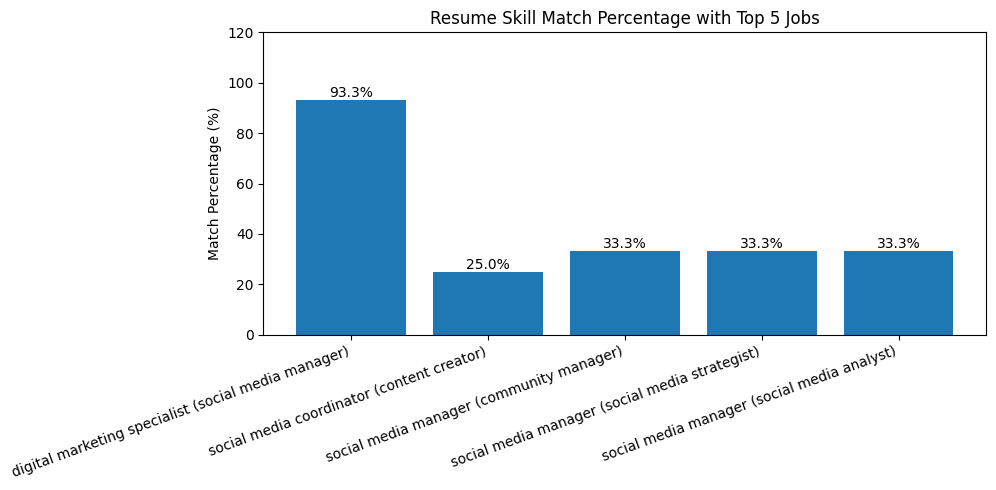

In [22]:
match_percentage = []

for m, miss in zip(matched_counts, missing_counts):
    total = m + miss
    match_percentage.append((m / total) * 100 if total > 0 else 0)

plt.figure(figsize=(10,5))
bars = plt.bar(labels, match_percentage)

plt.xticks(rotation=20, ha="right")
plt.ylabel("Match Percentage (%)")
plt.title("Resume Skill Match Percentage with Top 5 Jobs")
plt.ylim(0,120)

for bar, pct in zip(bars, match_percentage):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        pct + 1,
        f"{pct:.1f}%",
        ha='center'
    )

plt.tight_layout()
plt.savefig(f"Resume Skill Match Percentage with Top 5 Jobs{resume_id}.png", dpi=300, bbox_inches='tight')
plt.show()

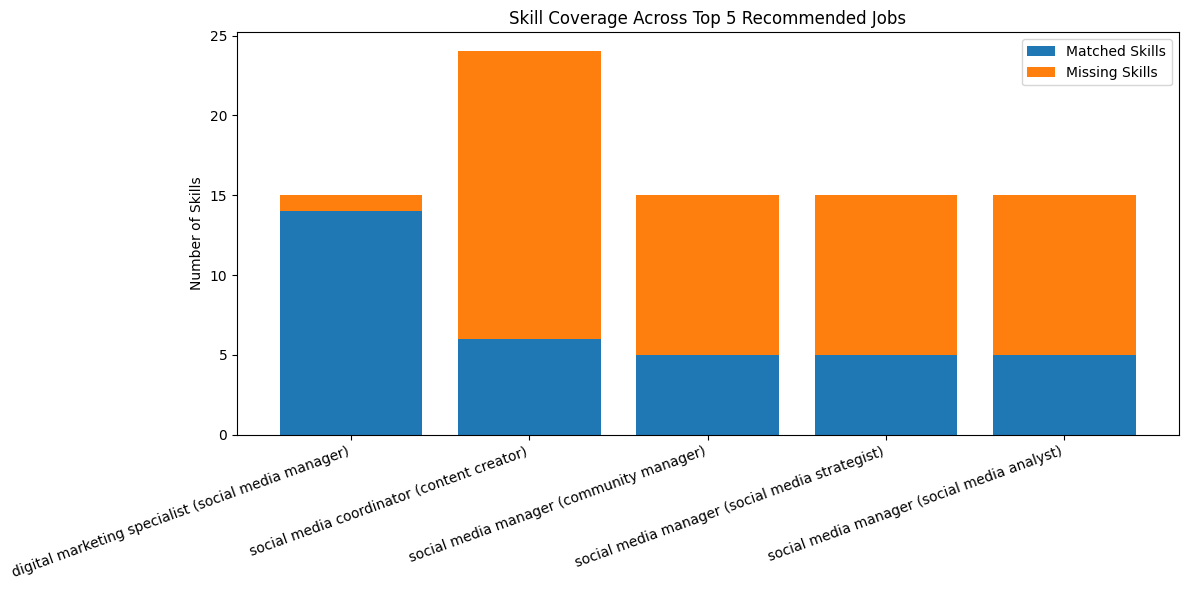

In [25]:
plt.figure(figsize=(12,6))

plt.bar(labels, matched_counts, label="Matched Skills")
plt.bar(labels, missing_counts, bottom=matched_counts, label="Missing Skills")

plt.xticks(rotation=20, ha="right")
plt.ylabel("Number of Skills")
plt.title("Skill Coverage Across Top 5 Recommended Jobs")
plt.legend()

plt.tight_layout()
plt.savefig(f"Skill Coverage Across Top 5 Recommended Jobs{resume_id}.png", dpi=300, bbox_inches='tight')
plt.show()